# Shor's Algorithm: Why PQC Matters NOW

This notebook demonstrates Shor's algorithm for factoring small numbers using Qiskit, and explains why current RSA encryption is vulnerable to quantum computers.

## The HNDL Threat
**Harvest Now, Decrypt Later (HNDL)**: Adversaries collect encrypted data today, planning to decrypt it when quantum computers are powerful enough. If your data needs to remain confidential for 10+ years, the threat is real *today*.

In [ ]:
try:
    import qiskit
    print(f"Qiskit version: {qiskit.__version__}")
except ImportError:
    print("Qiskit not installed. Install with: pip install qiskit[visualization]")
    print("This notebook requires the [quantum] extra: uv pip install zipminator[quantum]")

## Factoring N=15 with Shor's Algorithm
Shor's algorithm can factor integers in polynomial time on a quantum computer. Here we factor N=15 (= 3 x 5) using a simplified quantum circuit.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

# Simplified Shor's circuit for N=15, a=7
n_count = 8  # counting qubits
qc = QuantumCircuit(n_count + 4, n_count)

# Initialize counting qubits in superposition
for q in range(n_count):
    qc.h(q)

# Initialize target register to |1>
qc.x(n_count)

# Controlled modular exponentiation (simplified for N=15, a=7)
for q in range(n_count):
    power = 2**q
    # Simplified: apply controlled swaps for a^(2^q) mod 15
    if power % 4 == 1:
        qc.cswap(q, n_count, n_count+1)
        qc.cswap(q, n_count+1, n_count+2)
        qc.cswap(q, n_count+2, n_count+3)
    elif power % 4 == 3:
        qc.cswap(q, n_count+2, n_count+3)
        qc.cswap(q, n_count+1, n_count+2)
        qc.cswap(q, n_count, n_count+1)

# Inverse QFT on counting qubits
from qiskit.circuit.library import QFT
qc.append(QFT(n_count, inverse=True), range(n_count))
qc.measure(range(n_count), range(n_count))

print(f"Circuit depth: {qc.depth()}")
print(f"Total qubits: {qc.num_qubits}")
print(f"Classical bits: {qc.num_clbits}")
qc.draw('mpl', fold=40)

## Qubit Requirements: Today vs RSA-2048

Factoring N=15 requires ~12 qubits. But factoring RSA-2048 requires thousands of *logical* qubits, which in turn require millions of *physical* qubits due to error correction.

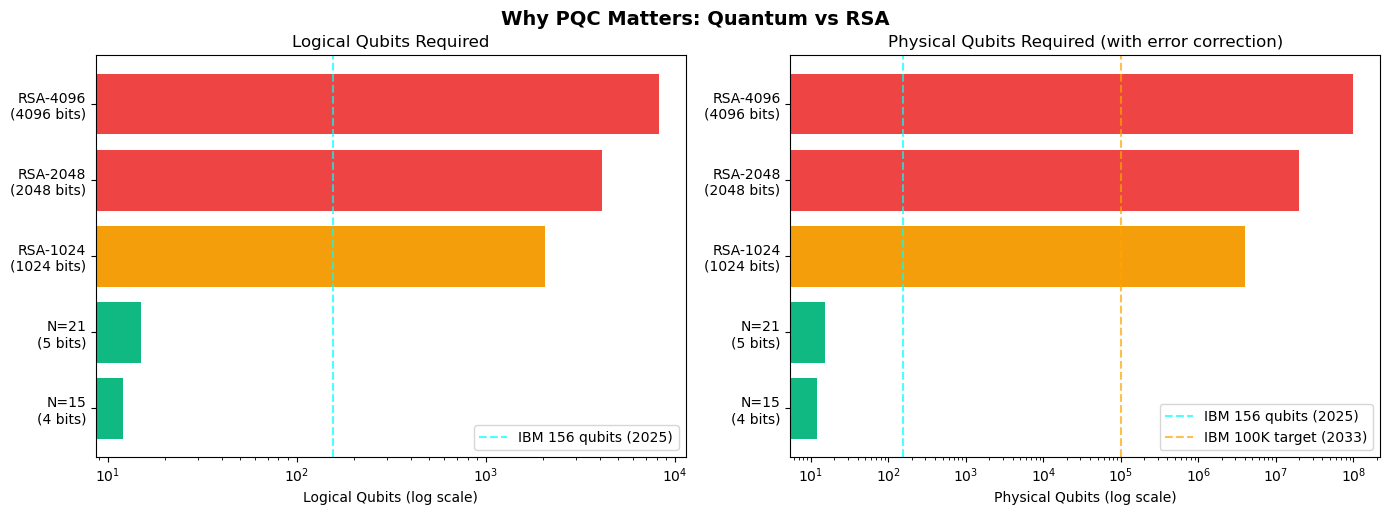

In [1]:
import matplotlib.pyplot as plt
import numpy as np

targets = ['N=15\n(4 bits)', 'N=21\n(5 bits)', 'RSA-1024\n(1024 bits)', 'RSA-2048\n(2048 bits)', 'RSA-4096\n(4096 bits)']
logical_qubits = [12, 15, 2048, 4098, 8196]
physical_qubits = [12, 15, 4_000_000, 20_000_000, 100_000_000]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Logical qubits (log scale)
colors = ['#10b981', '#10b981', '#f59e0b', '#ef4444', '#ef4444']
ax1.barh(targets, logical_qubits, color=colors)
ax1.set_xscale('log')
ax1.set_xlabel('Logical Qubits (log scale)')
ax1.set_title('Logical Qubits Required')
ax1.axvline(x=156, color='cyan', linestyle='--', alpha=0.7, label='IBM 156 qubits (2025)')
ax1.legend()

# Physical qubits (log scale)
ax2.barh(targets, physical_qubits, color=colors)
ax2.set_xscale('log')
ax2.set_xlabel('Physical Qubits (log scale)')
ax2.set_title('Physical Qubits Required (with error correction)')
ax2.axvline(x=156, color='cyan', linestyle='--', alpha=0.7, label='IBM 156 qubits (2025)')
ax2.axvline(x=100_000, color='orange', linestyle='--', alpha=0.7, label='IBM 100K target (2033)')
ax2.legend()

plt.tight_layout()
plt.suptitle("Why PQC Matters: Quantum vs RSA", y=1.02, fontsize=14, fontweight='bold')
plt.show()

## The Timeline

| Milestone | Year | Implication |
|-----------|------|-------------|
| Current largest quantum computer | 2025 | 1,000+ qubits (IBM Condor) |
| Qubit requirements reduced 95% | 2025 | Multiple research groups |
| NIST PQC standards finalized | 2024 | FIPS 203, 204, 205 |
| CNSA 2.0 deadline | 2027 | All new NSS must be PQC |
| Estimated CRQC (moderate) | 2035 | Cryptographically relevant QC |

## Conclusion

Even though we can't break RSA-2048 *today*, the **Harvest Now, Decrypt Later** threat means data encrypted with classical algorithms is already at risk. **Zipminator uses Kyber768 (ML-KEM-768)** to protect your data against both current and future quantum attacks.

In [2]:
# Use Zipminator's HNDL Risk Calculator
from zipminator.hndl_risk import HNDLCalculator

calc = HNDLCalculator()

# Scenario 1: Healthcare data with 50-year retention
result = calc.calculate(
    data_sensitivity="top_secret",
    retention_years=50,
    current_encryption="aes256",
    industry="healthcare",
)
print(f"Healthcare (AES-256, 50yr retention):")
print(f"  Risk: {result.overall_risk}/100 ({result.risk_level})")
print(f"  Years until quantum break: {result.years_until_quantum_break}")
print(f"  Recommendation: {result.recommended_action}")
print()

# Scenario 2: Same data with Kyber768
result2 = calc.calculate(
    data_sensitivity="top_secret",
    retention_years=50,
    current_encryption="kyber768",
    industry="healthcare",
)
print(f"Healthcare (Kyber768, 50yr retention):")
print(f"  Risk: {result2.overall_risk}/100 ({result2.risk_level})")
print(f"  Recommendation: {result2.recommended_action}")

Healthcare (AES-256, 50yr retention):
  Risk: 100.0/100 (CRITICAL)
  Years until quantum break: 9
  Recommendation: IMMEDIATE ACTION REQUIRED: Migrate to PQC encryption (ML-KEM-768/Kyber768). Your data will be exposed to quantum decryption within the retention period. Consider Zipminator Enterprise tier for QRNG + Kyber768 protection.

Healthcare (Kyber768, 50yr retention):
  Risk: 95.9/100 (CRITICAL)
  Recommendation: Your data is protected with post-quantum cryptography. Continue monitoring NIST standards updates.
